Import libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

Load the dataset

In [ ]:
#df = pd.read_csv(r'/content/drive/MyDrive/datasets/dataset.csv')
df = pd.read_csv('dataset.csv')

df.head()

,f1,f2,f3,f4,f5,f6,f7,target
0,6,148,72,35,0,33.6,0.627,1
1,1,85,66,29,0,26.6,0.351,0
2,8,183,64,0,0,23.3,0.672,1
3,1,89,66,23,94,28.1,0.167,0
4,0,137,40,35,168,43.1,2.288,1


Analyze the dataset

In [ ]:
print("="*15,"Info","="*15)
print(df.info())

print("="*15,"Shape","="*15)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("="*10,"Data Types","="*10)
print(df.dtypes)

print("="*10,"Numerical Stats","="*10)
print(df.describe())

print("="*35)

=============== Info ===============
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   f1      766 non-null    object
 1   f2      766 non-null    object
 2   f3      766 non-null    int64 
 3   f4      766 non-null    object
 4   f5      766 non-null    object
 5   f6      766 non-null    object
 6   f7      766 non-null    object
 7   target  766 non-null    int64 
dtypes: int64(2), object(6)
memory usage: 48.0+ KB
None
=============== Shape ===============
Rows: 766, Columns: 8
========== Data Types ==========
f1        object
f2        object
f3         int64
f4        object
f5        object
f6        object
f7        object
target     int64
dtype: object
========== Numerical Stats ==========
               f3      target
count  766.000000  766.000000
mean    69.118799    0.349869
std     19.376901    0.477240
min      0.000000    0.000000
25%     62.5

Handle invalid character entries

In [ ]:
df_cleaned = df.copy()

for col in df.columns:

    if df[col].dtype == 'object':
        unique_vals = df[col].unique()

        #regex for alphanumeric values
        invalid_vals = [v for v in unique_vals if not re.match(r'^[0-9a-zA-Z\.\-]*$', str(v))]

        if invalid_vals:
            print("Invalid values found: ")
        else:
            print("No invalid characters found.")

    else:

        col_str = df[col].astype(str)
        col_no_dot = col_str.str.replace('.', '', 1)
        is_digit = col_no_dot.str.isdigit()
        invalid_numeric = df[~is_digit]


        if not invalid_numeric.empty:
            print("Non-numeric values present in numeric column.")
            print(invalid_numeric.head())
        else:
            print("All numeric values are valid.")

    print("-" * 35)

    #Make sure the numerical columns do not include any random characters like '@,$',etc so conversion is more meaningful.
    #No invalid entries found, safe for conversion

No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
All numeric values are valid.
-----------------------------------
No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
No invalid characters found.
-----------------------------------
All numeric values are valid.
-----------------------------------


In [ ]:
for col in df_cleaned.columns:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')  # turn invalids into NaN
    print("NaNs in column",col, df_cleaned[col].isna().sum())
    median_val = df_cleaned[col].median()
    df_cleaned.fillna({col:median_val}, inplace=True)

print("All invalid entries handled successfully!")
print(df_cleaned.info())
print(df_cleaned.head())

# Convert the non-numeric columns to numeric and turn invalid entries into NaN, then we fill these NaN values with median of that column
# We also print the number of NaN values on each column and in this dataset. The fact that dataset contains no invalid
# entries(last step) supports the absence of NaNs also.

NaNs in column f1 1
NaNs in column f2 1
NaNs in column f3 0
NaNs in column f4 1
NaNs in column f5 1
NaNs in column f6 1
NaNs in column f7 1
NaNs in column target 0
All invalid entries handled successfully!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      766 non-null    float64
 1   f2      766 non-null    float64
 2   f3      766 non-null    int64  
 3   f4      766 non-null    float64
 4   f5      766 non-null    float64
 5   f6      766 non-null    float64
 6   f7      766 non-null    float64
 7   target  766 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.0 KB
None
    f1     f2  f3    f4     f5    f6     f7  target
0  6.0  148.0  72  35.0    0.0  33.6  0.627       1
1  1.0   85.0  66  29.0    0.0  26.6  0.351       0
2  8.0  183.0  64   0.0    0.0  23.3  0.672       1
3  1.0   89.0  66  23.0   94.0  28.1  0.167       0
4  0

4. Data Visulisation

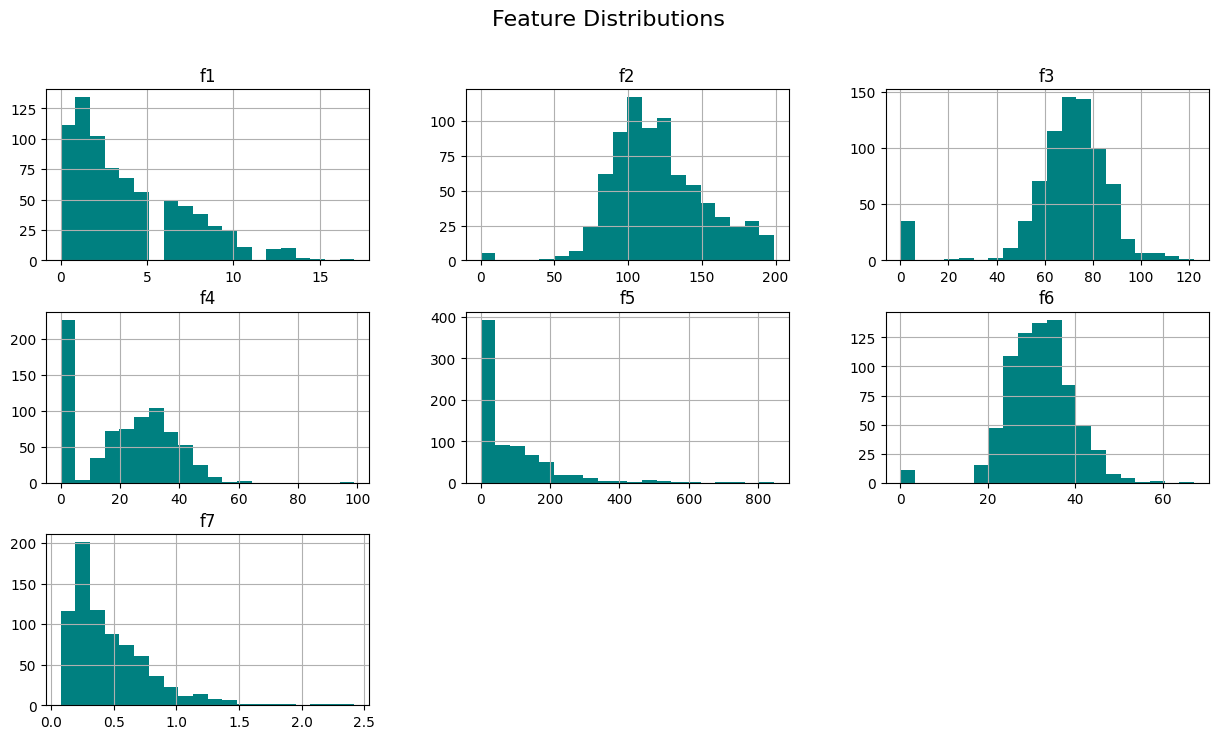

In [ ]:
df_cleaned[['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7']].hist(bins=20, figsize=(15, 8), color="teal")
plt.suptitle('Feature Distributions', fontsize=16)
plt.show()

# Representation of each input column values on a histogram. Shows how the values are distributed. From the result, columns 'f3','f4'
# and'f6' resemble the normal distribuition curve.


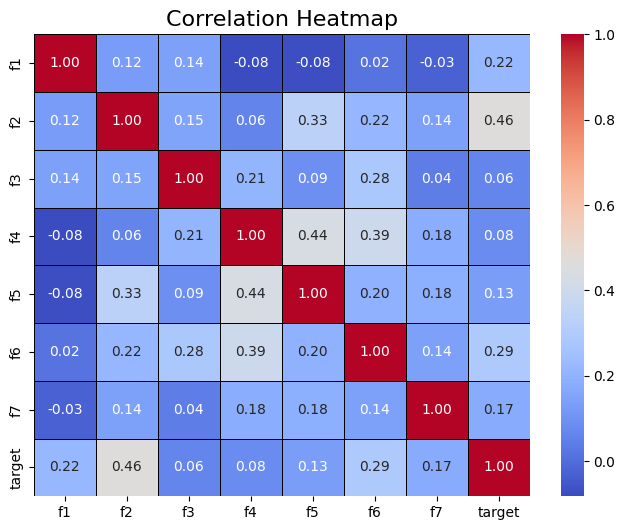

In [ ]:

plt.figure(figsize=(8,6))
corr = df_cleaned.astype(float).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f",linecolor='black', linewidths=0.7)
plt.title('Correlation Heatmap', fontsize=16)
plt.show()


# The graph below shows the correlation between feature inputs and target column with each other. For this, first we have to calculate
# the correlation matrix and then represent it using heatmap from seaborn library. We can observe from the result that correlation between
# target and f2 is highest (0.46) which means it must be an important feature to predict target. f3 and the target has lowest correlation
# value (0.06) which means it contributes very less to target variable.

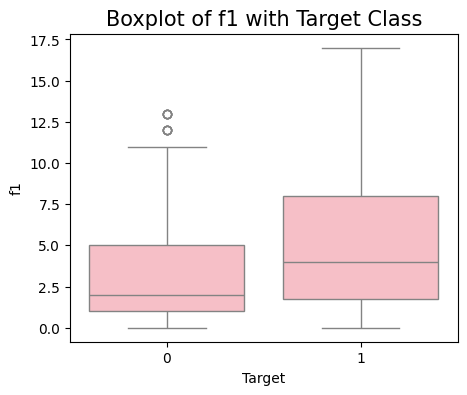

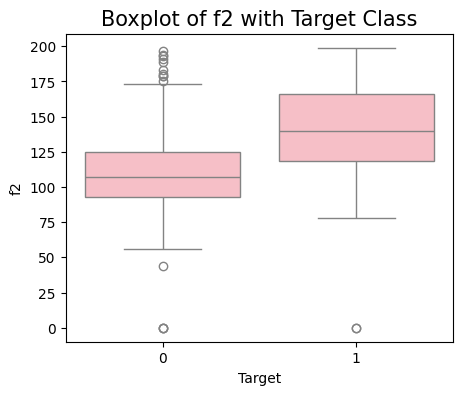

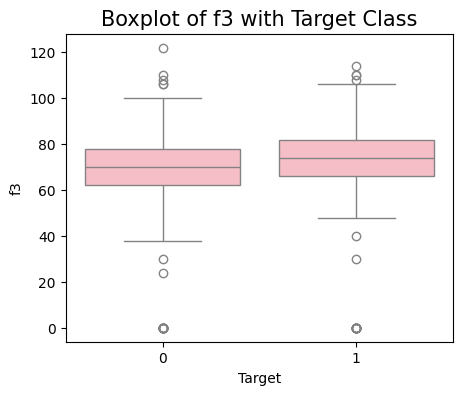

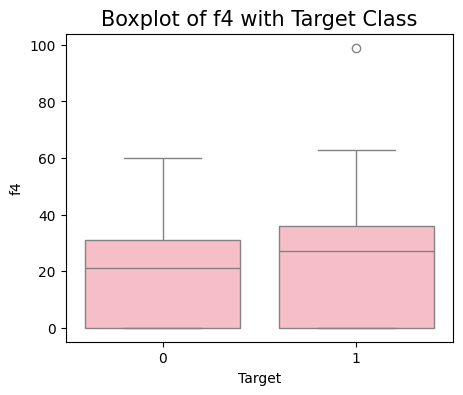

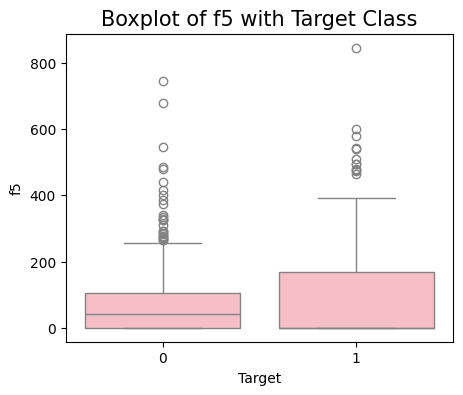

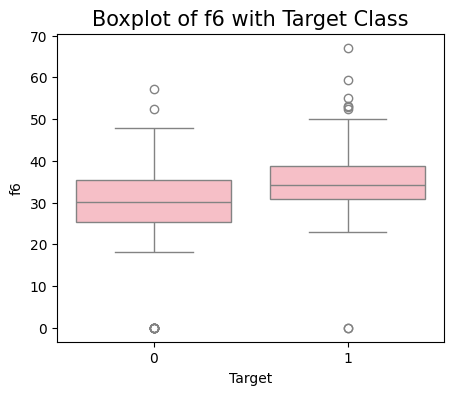

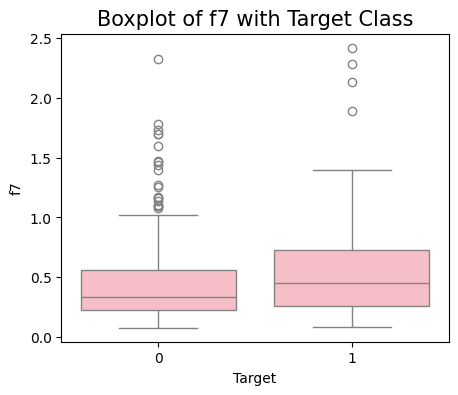

In [ ]:
for col in df_cleaned.columns:
    if col == 'target':  # skip target column
        continue

    plt.figure(figsize=(5,4))
    sns.boxplot(x='target', y=col, data=df_cleaned.astype({col: float}), color = "lightpink")
    plt.title(f'Boxplot of {col} with Target Class', fontsize=15)
    plt.xlabel('Target')
    plt.ylabel(col)
    plt.show()

    # Here we represent box plot of each column with target values (0 and 1). This will help us to identify important trends such as if
    # the value of target is 0, the value of feature input lets say f3 is higher or lower then when the value of target is 1. We have
    # created this plot for each column which will help us identify such relations in each input column with respect to target variable.
    # Additionally, we can visualise the outliers in each input column.


Preprocessing Using Normalize

In [ ]:
import torch
from torch.nn.functional import normalize

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

print(f" Type of dataset Before: \n {df_cleaned.info()}")

#Convert to tensor datatype
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df_cleaned.drop('target', axis=1).values)
x_tensorData = torch.tensor(x_scaled, dtype=torch.float32)

#x_tensorData = torch.tensor(df_cleaned.drop('target', axis=1).values, dtype=torch.float32)
y_tensorData = torch.tensor(df_cleaned['target'].values, dtype=torch.long)

print(f"After converting to tensor type (Features): \n{x_tensorData}")

print(f" Feature Tensor type: \n{x_tensorData.dtype}")

print(f" After converting to tensor type (Target): \n{y_tensorData}")

print(f" Target Tensor type: \n{y_tensorData.dtype}")

print(f"\n✅ Original class counts:")
print(f"Positive class: {torch.sum(y_tensorData == 1).item()}")
print(f"Negative class: {torch.sum(y_tensorData == 0).item()}")

X_np = x_tensorData.numpy()
y_np = y_tensorData.numpy()

# Apply RandomOverSampler
ros = RandomOverSampler(random_state=42)
X_resampled_np, y_resampled_np = ros.fit_resample(X_np, y_np)

# Convert back to tensors
X_resampled = torch.tensor(X_resampled_np, dtype=torch.float32)
y_resampled = torch.tensor(y_resampled_np, dtype=torch.long)

print(f"\n✅ After RandomOverSampler:")
print(f"Positive class: {torch.sum(y_resampled == 1).item()}")
print(f"Negative class: {torch.sum(y_resampled == 0).item()}")

'''
#Now lets normalise
x_tensorData_normalise = normalize(x_tensorData,p=2,dim=1)
#Using l2 normalisation

print(f" After normalisation (first 3 rows): \n{x_tensorData_normalise[:3]}")
'''

#In our data set before preprocessing we had converted all categorical colums to numerical colums
#and based on that we could apply either standardscaling or normalization. We have choosen normalisation as
#we are not planning to find the standard deviation and build a SVM , Logistic regression model.
#And normalisation are generally helpful in building models that are essential for neural network building

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 766 entries, 0 to 765
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   f1      766 non-null    float64
 1   f2      766 non-null    float64
 2   f3      766 non-null    int64  
 3   f4      766 non-null    float64
 4   f5      766 non-null    float64
 5   f6      766 non-null    float64
 6   f7      766 non-null    float64
 7   target  766 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 48.0 KB
 Type of dataset Before: 
 None
After converting to tensor type (Features): 
tensor([[ 0.6385,  0.8492,  0.1488,  ..., -0.6945,  0.2031,  0.4681],
        [-0.8454, -1.1253, -0.1611,  ..., -0.6945, -0.6844, -0.3654],
        [ 1.2321,  1.9462, -0.2643,  ..., -0.6945, -1.1027,  0.6040],
        ...,
        [-0.5486,  0.0343,  0.0455,  ..., -0.3821,  0.6088, -0.3986],
        [-0.2518,  0.0030,  0.1488,  ...,  0.2774, -0.7351, -0.6855],
        [-0.8454,  0.1597, -0.4709,

'\n#Now lets normalise\nx_tensorData_normalise = normalize(x_tensorData,p=2,dim=1)\n#Using l2 normalisation\n\nprint(f" After normalisation (first 3 rows): \n{x_tensorData_normalise[:3]}")\n'

Splitting the dataset

In [ ]:
from sklearn.model_selection import train_test_split

X_main, X_test, y_main, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42,stratify=y_resampled)


#X_main, X_test, y_main, y_test = train_test_split(x_tensorData_normalise, y_tensorData, test_size=0.2, random_state=42)

print(f"Shape of X_main: {X_main.shape}")
print(f"Shape of y_main: {y_main.shape}")

print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")

#Now splitting training data again into validation

X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=0.2, random_state=42,stratify=y_main)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")

print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_val: {y_val.shape}")


import sklearn
print(sklearn.__version__)


Shape of X_main: torch.Size([796, 7])
Shape of y_main: torch.Size([796])
Shape of X_test: torch.Size([200, 7])
Shape of y_test: torch.Size([200])
Shape of X_train: torch.Size([636, 7])
Shape of y_train: torch.Size([636])
Shape of X_val: torch.Size([160, 7])
Shape of y_val: torch.Size([160])
1.6.1


 Defining the Neural Network


In [ ]:
!pip install torchinfo


In [ ]:
import torch
import torch.nn as nn
from torchinfo import summary

class NeuralNet(nn.Module):
    def __init__(self, input_dim=7):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 1)
        #self.output = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        #x = self.output(x)  # no sigmoid here!
        x = self.sigmoid(self.output(x))  # binary classification output
        return x

model = NeuralNet(input_dim=7)

print(model)

summary(model, input_size=(1, 7))


NeuralNet(
  (fc1): Linear(in_features=7, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=1, bias=True)
  (relu): ReLU()
  (sigmoid): Sigmoid()
  (dropout): Dropout(p=0.5, inplace=False)
)


Layer (type:depth-idx)                   Output Shape              Param #
NeuralNet                                [1, 1]                    --
├─Linear: 1-1                            [1, 128]                  1,024
├─ReLU: 1-2                              [1, 128]                  --
├─Dropout: 1-3                           [1, 128]                  --
├─Linear: 1-4                            [1, 64]                   8,256
├─ReLU: 1-5                              [1, 64]                   --
├─Dropout: 1-6                           [1, 64]                   --
├─Linear: 1-7                            [1, 1]                    65
├─Sigmoid: 1-8                           [1, 1]                    --
Total params: 9,345
Trainable params: 9,345
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.04
Estimated Total Size (MB): 0.04

Training the neural network

In [ ]:
import torch.nn as nn
import torch.optim as optim

#lossFunction = nn.BCEWithLogitsLoss()
lossFunction = nn.BCELoss()
print('Loss function : ',lossFunction)


#pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()
#lossFunction = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_val]))

optimiser = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

#optimiser = torch.optim.Adam(model.parameters(), lr=0.0001,weight_decay=1e-5)
print('Optimiser : ',optimiser)


Loss function :  BCELoss()
Optimiser :  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 1e-05
)


In [ ]:

import time

Path = "rajagop6_diksh_bestweights_model"
best_model_score = float('inf')

numberOfEpochs = 100

batchSize = 32


batchToProcess = (len(X_train)+batchSize-1) // batchSize
#Above includes all the features present in the batch so that none gets dropped

start_time = time.time()
print(f"Batch to process at a go: {batchToProcess}")

for epoch in range(numberOfEpochs):
  perm = torch.randperm(X_train.size(0))
  X_train = X_train[perm]
  y_train = y_train[perm]
  for i in range(batchToProcess):
    X_train_batch = X_train[i*batchSize:(i*batchSize)+batchSize]
    y_train_batch = y_train[i*batchSize:(i*batchSize)+batchSize]


    outputs = model(X_train_batch)
    loss = lossFunction(outputs.squeeze(),y_train_batch.float())
    optimiser.zero_grad()
    loss.backward()
    optimiser.step()

    print(f"Epoch at current step:{epoch+1} and loss: {loss.item()}")

  #calculate values for validation dataset
  model.eval()
  with torch.no_grad():
    outputs_val = model(X_val)
    loss_val = lossFunction(outputs_val.squeeze(), y_val.float())
    print(f"Validation loss at epoch: {epoch+1} and loss: {loss_val.item()}")

    if loss_val.item() < best_model_score:
      best_model_score = loss_val.item()
      torch.save(model.state_dict(), Path)
      print(f"Model saved at epoch: {epoch+1} and loss: {best_model_score}")

  model.train() #Shifting back to original so that it runs properly for other epochs

end_time = time.time()
print(f"Ttime taken: {end_time - start_time} seconds")


Batch to process at a go: 20
Epoch at current step:1 and loss: 0.6882611513137817
Epoch at current step:1 and loss: 0.7033498883247375
Epoch at current step:1 and loss: 0.6780436038970947
Epoch at current step:1 and loss: 0.7247098684310913
Epoch at current step:1 and loss: 0.7242414951324463
Epoch at current step:1 and loss: 0.7280288338661194
Epoch at current step:1 and loss: 0.6816564798355103
Epoch at current step:1 and loss: 0.7142817974090576
Epoch at current step:1 and loss: 0.6842982172966003
Epoch at current step:1 and loss: 0.7304469347000122
Epoch at current step:1 and loss: 0.6660199761390686
Epoch at current step:1 and loss: 0.6659955382347107
Epoch at current step:1 and loss: 0.7079173922538757
Epoch at current step:1 and loss: 0.7198147773742676
Epoch at current step:1 and loss: 0.6777199506759644
Epoch at current step:1 and loss: 0.703169584274292
Epoch at current step:1 and loss: 0.7044722437858582
Epoch at current step:1 and loss: 0.7134580612182617
Epoch at current s

Evaluate the performance of the model on the testing data

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score



model.eval()
with torch.no_grad():
    y_pred_logits = model(X_test)
    y_pred_probs = torch.sigmoid(y_pred_logits.squeeze())
    y_pred_labels = (y_pred_probs >= 0.6).float()

y_true = y_test.cpu().numpy()
y_pred_labels_np = y_pred_labels.cpu().numpy()
print(y_pred_labels_np)



accuracy = accuracy_score(y_true, y_pred_labels_np)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred_labels_np, average='binary', zero_division=0
)



[1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1. 0. 1.
 0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 0. 1. 1. 0. 0. 1. 1.
 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 0. 0. 1. 1. 1. 1. 0. 0. 1.
 1. 0. 0. 1. 1. 0. 1. 1. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0. 0. 0. 1. 0. 0.
 1. 1. 0. 1. 1. 0. 0. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 1. 1. 1. 0. 1.
 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 0. 1. 1. 1. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 1. 1. 1. 0. 0. 0.
 1. 1. 1. 1. 0. 1. 1. 1.]


In [ ]:
print("=== Model Evaluation on Test Data ===")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")


=== Model Evaluation on Test Data ===
Accuracy : 0.7500
Precision: 0.7119
Recall   : 0.8400
F1 Score : 0.7706


References:

1.https://seaborn.pydata.org/generated/seaborn.heatmap.html

2.https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.normalize.html
3.https://docs.pytorch.org/tutorials/beginner/introyt/introyt_index.html
